In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Step 1: Load the .txt file
df = pd.read_csv('electricity.txt', sep=';', low_memory=False)

# Step 2: Combine Date and Time into a single column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Step 3: Drop old Date and Time columns
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Step 4: Set Datetime as index
df.set_index('Datetime', inplace=True)

# Step 5: Convert all other columns to numeric (coerce errors to NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Step 6: Handle missing values (optional: you can drop or fill)
df.dropna(inplace=True)

# Step 7: Save cleaned data
df.to_csv('electricity.csv')

# Show the first few rows
df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2049280 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 125.1 MB
None
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091615e+00           1.237145e-01  2.408399e+02   
std           1.057294e+00           1.127220e-01  3.239987e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1

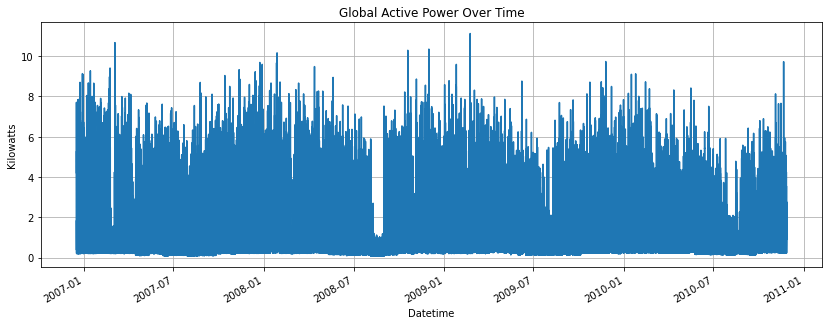

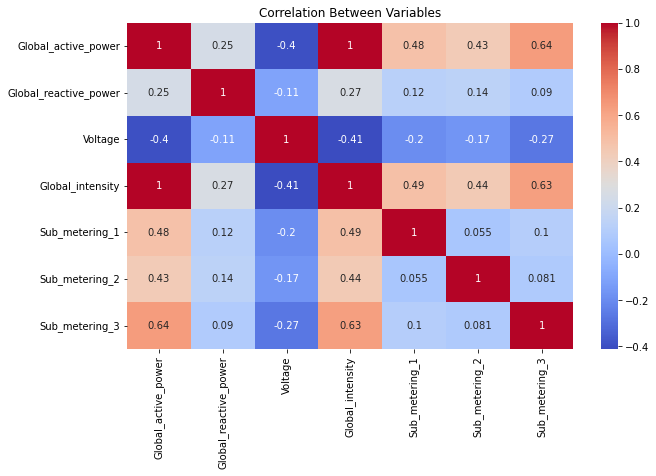

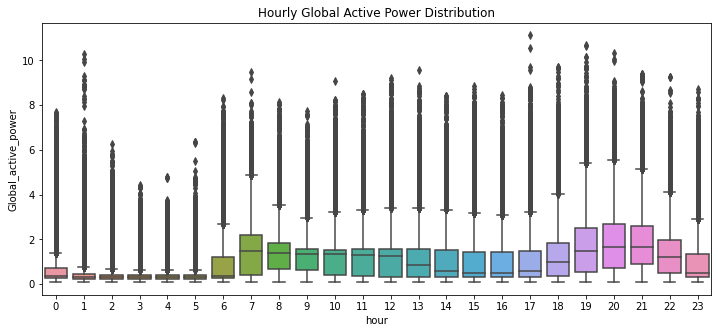

In [15]:
# Load cleaned data
df = pd.read_csv('electricity.csv', index_col='Datetime', parse_dates=True)

# Basic info
print(df.info())
print(df.describe())

# Plot overall usage trend
plt.figure(figsize=(14, 5))
df['Global_active_power'].plot(title='Global Active Power Over Time')
plt.ylabel('Kilowatts')
plt.grid(True)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Variables')
plt.show()

# Daily usage pattern
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

# Boxplot by hour
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='hour', y='Global_active_power')
plt.title('Hourly Global Active Power Distribution')
plt.show()

# Clean extra columns after EDA
df.drop(['hour', 'dayofweek'], axis=1, inplace=True)


In [16]:
# Load data
df = pd.read_csv('electricity.csv', index_col='Datetime', parse_dates=True)
df = df.resample('H').mean()  # resample to hourly to smoothen

# Split train/test
train = df.iloc[:-48]  # last 2 days as test
test = df.iloc[-48:]

# Train ARIMA
model = ARIMA(y, order=(2, 1, 2))  # y is your time series
model_fit = model.fit()
# Forecast
forecast = model_fit.forecast(steps=10)
forecast.index = test.index

# Plot forecast vs actual
plt.figure(figsize=(12,5))
plt.plot(train['Global_active_power'], label='Train')
plt.plot(test['Global_active_power'], label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title('Global Active Power Forecast')
plt.grid()
plt.show()

# Error
mse = mean_squared_error(test['Global_active_power'], forecast)
print(f'MSE: {mse:.4f}, RMSE: {np.sqrt(mse):.4f}')

NameError: name 'y' is not defined

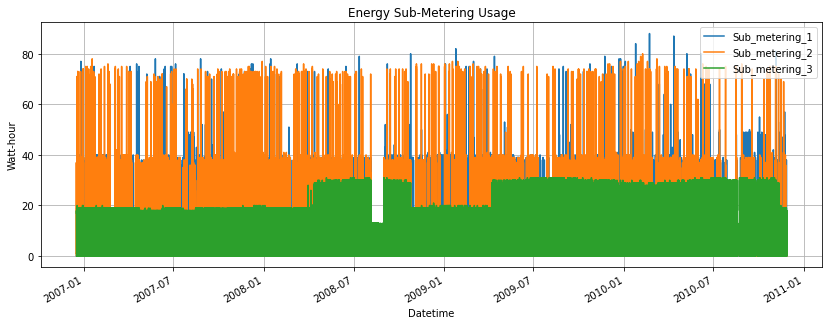

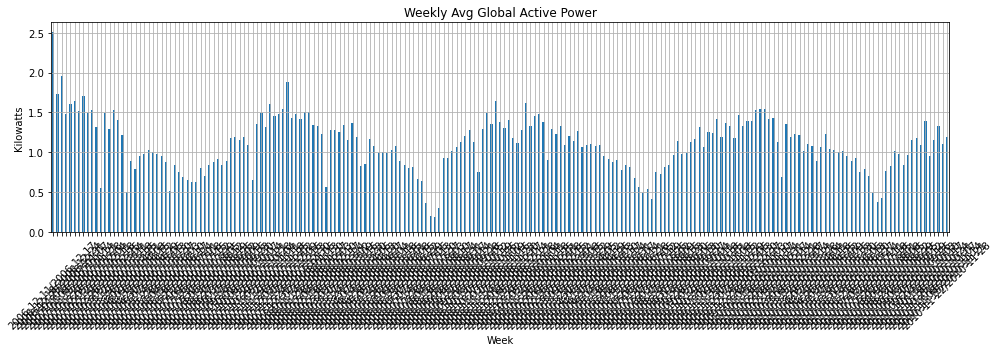

In [17]:
df = pd.read_csv('electricity.csv', index_col='Datetime', parse_dates=True)

# Compare sub-metering usage
df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].plot(figsize=(14, 5))
plt.title('Energy Sub-Metering Usage')
plt.ylabel('Watt-hour')
plt.grid()
plt.show()

# Weekly average usage
df['Week'] = df.index.to_period('W')
weekly = df.groupby('Week').mean()

weekly['Global_active_power'].plot(kind='bar', figsize=(14, 5), title='Weekly Avg Global Active Power')
plt.ylabel('Kilowatts')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()


In [18]:
import joblib

# After training
joblib.dump(model_fit, 'model.pkl')


['model.pkl']